In [23]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as u

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from astropy.visualization import simple_norm

import glob
from PIL import Image
import os
from IPython import display


In [ ]:
#load data 
# observed data cube
data_cube = fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/S2349+2904_HIcube2_clean_smooth_image_5_cube_kms.fits")
data_header =fits.getheader("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/S2349+2904_HIcube2_clean_smooth_image_5_cube_kms.fits")

# mask 
data_mask= fits.getdata("/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/S2349+2904_HIcube2_clean_smooth_image_5_mask_kms.fits")
#
#data models
directory_7753 = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7753/"
data_model_ngc7753 = fits.getdata(directory_7753 + "output3/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")
#
directory_7752 = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/NGC7752/"
data_model_ngc7752 = fits.getdata(directory_7752 + "output/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")
#
directory_companion = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/USNOA2-1125-19940303/"
data_model_companion = fits.getdata(directory_companion+"output/SoFiA_J234703.61+292835.6/SoFiA_J234703.61+292835.6mod_azim.fits")


In [3]:
# residuals for the system
#data_residual_system= data_cube - (data_model_ngc7753 + data_model_ngc7752 + data_model_companion)
# final model for the system
data_system_model=data_model_ngc7753 + data_model_ngc7752 + data_model_companion

In [4]:
#
# data_mask1 = np.where(data_mask,data_residual_system,0)

In [5]:
# compute rms for threshold
rms1 = np.nanstd(data_cube)
#rms2 = np.nanstd(data_mask1)
#print(rms1, rms2)

In [6]:
#data_cube_masked = np.where(data_cube > 2*rms1, data_cube, 0)
#data_residual_masked = np.where(data_mask1 > 2*rms2, data_mask1, 0)
masked = np.where(data_mask, data_cube,0)
data_cube_masked1 = np.where(masked > 2*rms1,masked,0)
masked_residual = data_cube_masked1- data_system_model
rms2=np.nanstd(masked_residual)
#print(rms1, rms2)
data_residual_masked = np.where(masked_residual > 2*rms2, masked_residual,0)

In [7]:
print(np.nanmax(data_system_model),np.nanmin(data_system_model))
print(np.arange(np.nanmin(data_system_model)+0.004,np.nanmax(data_system_model),0.002))

0.018330306 0.0
[0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018]


In [47]:
def channelmaps(data_observed,data_model,data_residual,name_system):
    for i in range(data_observed.shape[0]):
#for i in range(0,3):
        fig = plt.figure(figsize=(11,10))
        ax = fig.add_subplot()
        plt.imshow(data_observed[i,:,:])
        plt.contour(data_observed[i,:,:], levels=[np.percentile(data_observed[i,:,:],98.8)], colors='w')
        #plt.contour(data_residual[i,:,:], levels=[np.percentile(data_model[i,:,:],98.8)], colors='r')
        plt.contour(data_model[i,:,:], levels=np.arange(np.nanmin(data_system_model)+0.004,np.nanmax(data_system_model),0.002), colors='r')
#        plt.contour(data_residual[i,:,:], levels=[np.percentile(data_residual[i,:,:],98.8)], colors='g')
#        plt.contour(data_observed[i,:,:], levels=2, colors='w')
#        plt.contour(data_model[i,:,:], levels=2, colors='r')
#        #plt.contour(data_residual[i,:,:], levels=2, colors='g')
        ax.set_xlabel('RA', size=18,family='serif')
        ax.set_ylabel('Dec', size=18,family='serif')
        #plt.xlim([0,9])
        #plt.ylim([0,9])
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)

        plt.savefig('plots2/{}_{:02d}.png'.format(name_system, i)) # saving the figure using all 2 digit numbers
        plt.close()
    # input images
    images_input = 'plots2/{}_***.png'.format(name_system)
    # output gif
    imgif_output = 'plots2/{}_animation.gif'.format(name_system)

    # Collect the images
    imgs = (Image.open(f) for f in sorted(glob.glob(images_input)))

    img = next(imgs)

    # save the gif file
    img.save(fp = imgif_output, format = "GIF", append_images = imgs, save_all = True, duration = 300, loop = 0)
    # Show the animation
    display.Image('plots2/{}_animation.gif'.format(name_system))

In [53]:
channelmaps(data_cube_masked1,data_system_model,data_cube,"Arp86")

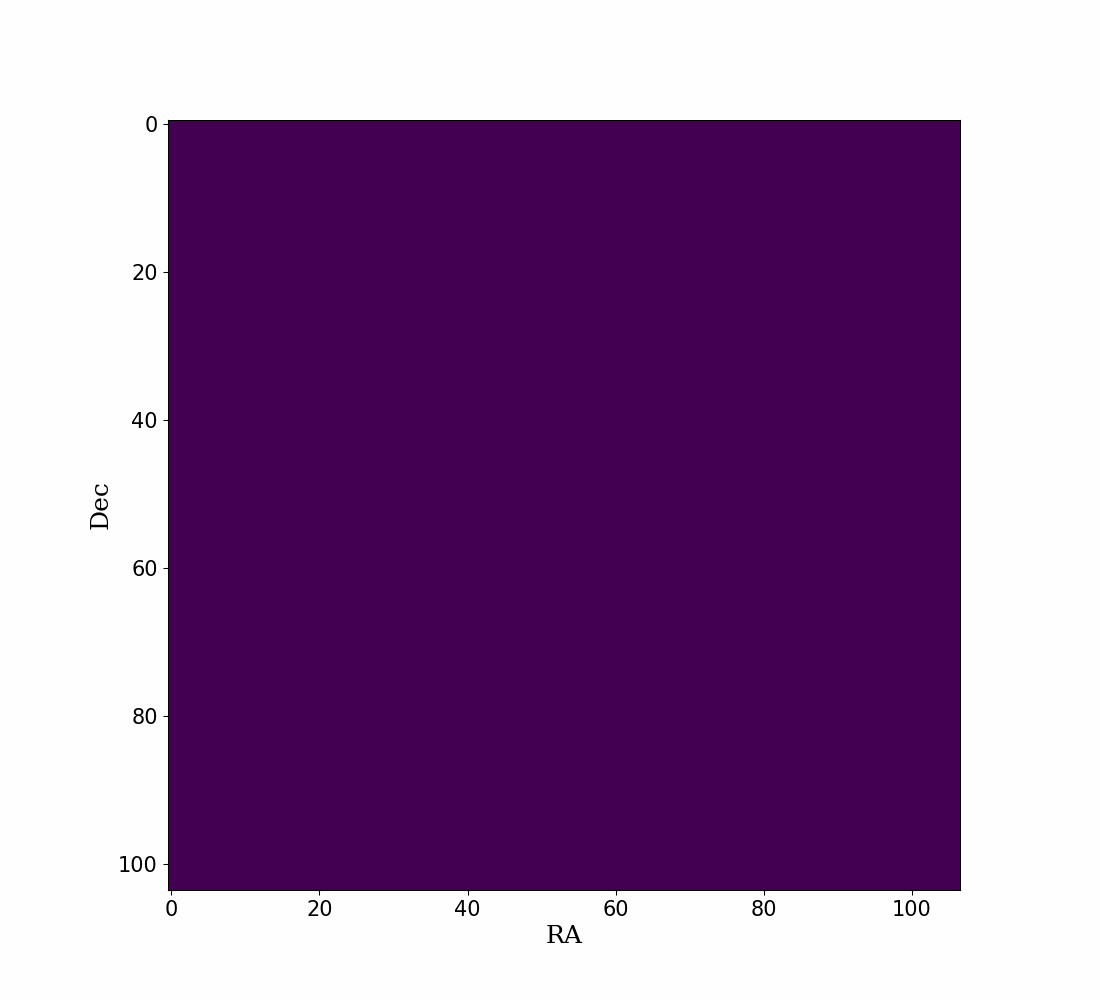

In [54]:
display.Image('plots2/{}_animation.gif'.format("Arp86"))

In [8]:
x_axis = (np.arange(data_cube.shape[0]) * data_header['CDELT3'] +
              (data_header['CRVAL3'] - data_header['CRPIX3'] * data_header['CDELT3'])) / 1000

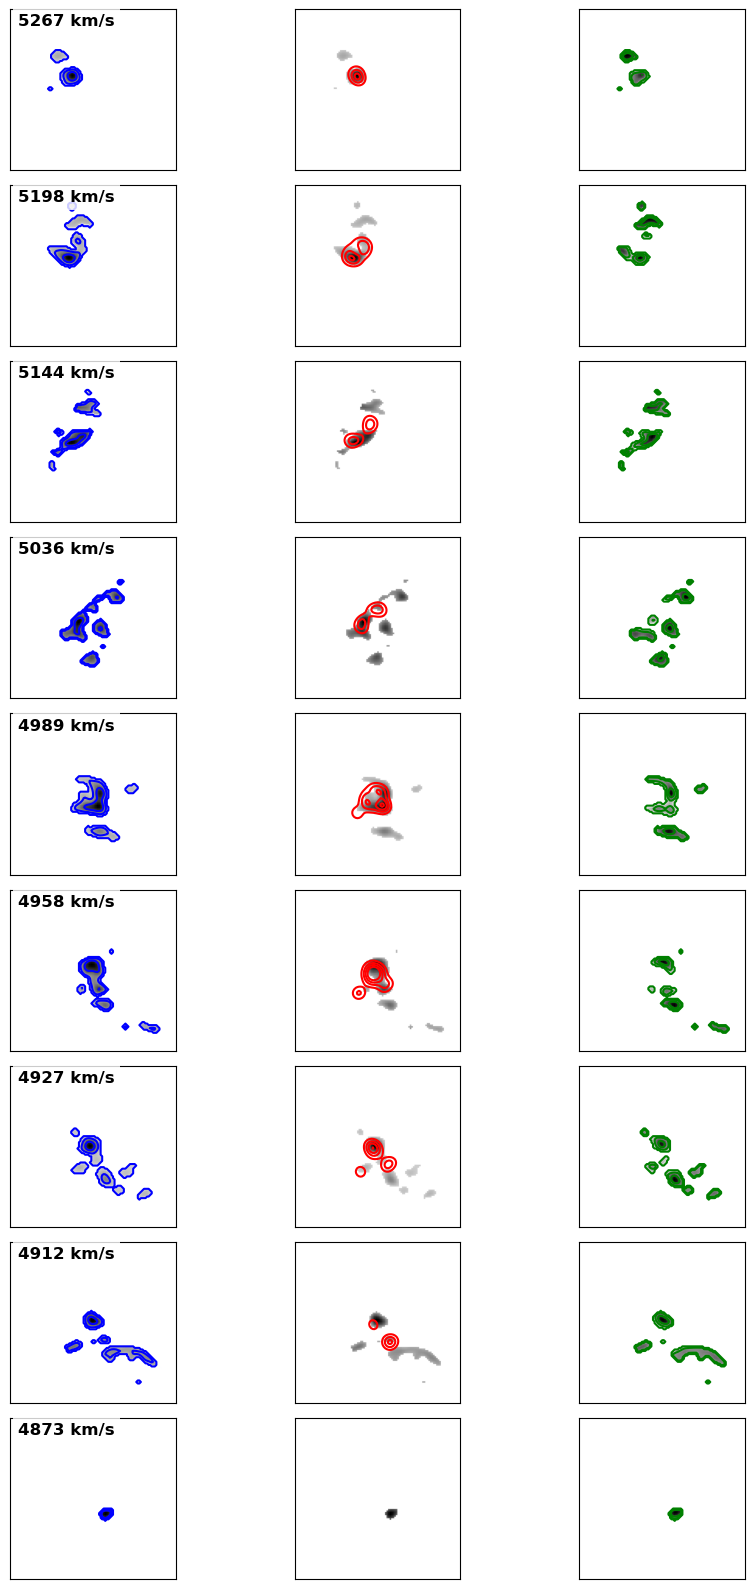

In [9]:
# Example: channels and their velocities (replace with your actual values)
n_channels = [14,23,30,44,50,54,58,60,65]
velocities = [int(x_axis[14]), int(x_axis[23]), int(x_axis[30]), int(x_axis[44]), int(x_axis[50]), int(x_axis[54]), int(x_axis[58]), int(x_axis[60]), int(x_axis[65])]  # km/s, one per channel

fig, axes = plt.subplots(len(n_channels), 3, figsize=(10, 16))

for j, (i, vel) in enumerate(zip(n_channels, velocities)):
    # Data: axes[j, 0]
    axes[j, 0].imshow(data_cube_masked1[i, :, :], origin='lower', cmap='gray_r', aspect='equal')
    axes[j, 0].contour(data_cube_masked1[i, :, :], levels=2, colors='blue', linewidths=1.5)
    axes[j, 0].text(0.05, 0.90, f'{vel} km/s', transform=axes[j, 0].transAxes,
                    fontsize=12, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    
    # Model: axes[j, 1]
    axes[j, 1].imshow(data_cube_masked1[i, :, :], origin='lower', cmap='gray_r', aspect='equal')
    axes[j, 1].contour(data_system_model[i, :, :], levels=[0.003,0.006,0.009,0.012], colors='red', linewidths=1.5)

    # Residual: axes[j, 2]
    axes[j, 2].imshow(data_residual_masked[i, :, :], origin='lower', cmap='gray_r', aspect='equal')
    axes[j, 2].contour(data_residual_masked[i, :, :], levels=2, colors='green', linewidths=1.5)

    # Remove ticks and labels for a clean look
    for k in range(3):
        axes[j, k].set_xticks([])
        axes[j, k].set_yticks([])
        axes[j, k].set_xlabel('')
        axes[j, k].set_ylabel('')

plt.subplots_adjust(wspace=0.001, hspace=0.12)

plt.tight_layout()
plt.show()

In [25]:
np.shape(data_model_ngc7753)

(94, 104, 107)

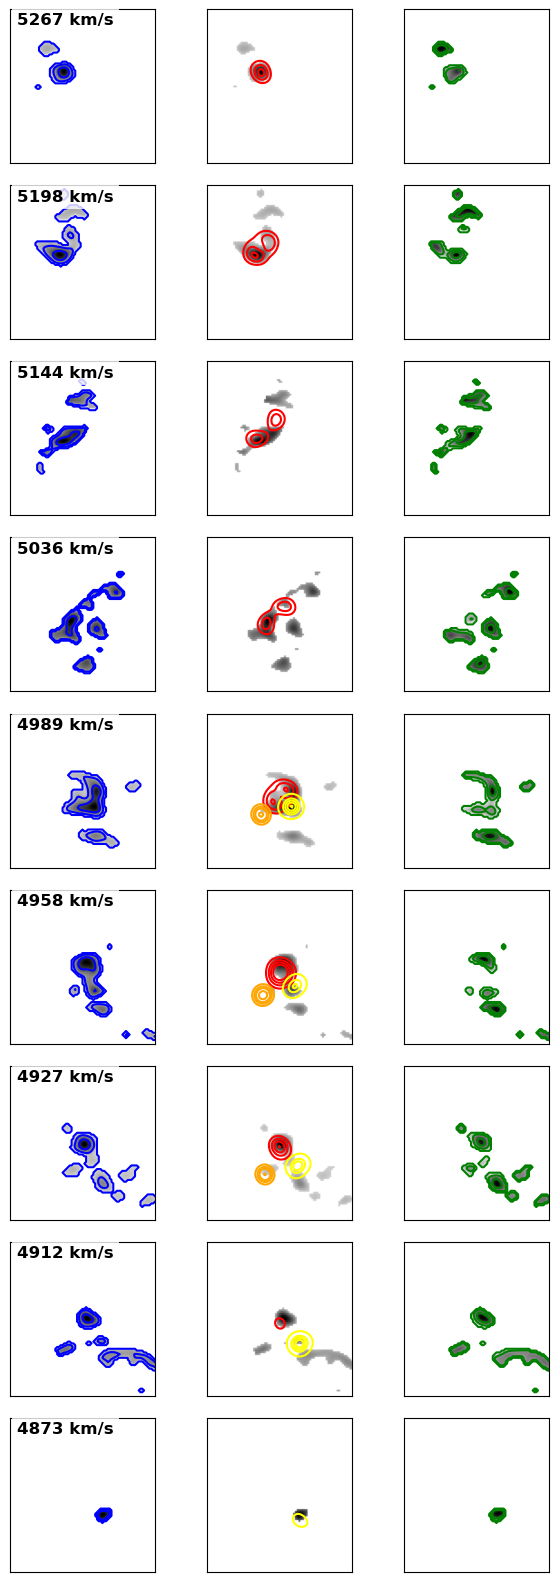

In [34]:
# Example: channels and their velocities (replace with your actual values)
n_channels = [14,23,30,44,50,54,58,60,65]
velocities = [int(x_axis[14]), int(x_axis[23]), int(x_axis[30]), int(x_axis[44]), int(x_axis[50]), int(x_axis[54]), int(x_axis[58]), int(x_axis[60]), int(x_axis[65])]  # km/s, one per channel

fig, axes = plt.subplots(len(n_channels), 3, figsize=(6, 16))

for j, (i, vel) in enumerate(zip(n_channels, velocities)):
    # Data: axes[j, 0]
    axes[j, 0].imshow(data_cube_masked1[i, :, :], origin='lower', cmap='gray_r', aspect='equal')
    axes[j, 0].contour(data_cube_masked1[i, :, :], levels=2, colors='blue', linewidths=1.5)
    axes[j, 0].text(0.05, 0.90, f'{vel} km/s', transform=axes[j, 0].transAxes,
                    fontsize=12, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    axes[j,0].set_xlim(10,90)
    axes[j,0].set_ylim(10,95)
    
    # Model: axes[j, 1]
    axes[j, 1].imshow(data_cube_masked1[i, :, :], origin='lower', cmap='gray_r', aspect='equal')
    #axes[j, 1].contour(data_system_model[i, :, :], levels=[0.003,0.006,0.009,0.012], colors='red', linewidths=1.5)
    axes[j, 1].contour(data_model_ngc7753[i, :, :], levels=[0.003,0.006,0.009,0.012], colors='red', linewidths=1.5)
    axes[j, 1].contour(data_model_ngc7752[i, :, :], levels=[0.001, 0.004,0.006,0.008,0.01], colors='yellow', linewidths=1.5)
    axes[j, 1].contour(data_model_companion[i, :, :], levels=[0.001, 0.002,0.003,0.005], colors='orange', linewidths=1.5)
    axes[j,1].set_xlim(10,90)
    axes[j,1].set_ylim(10,95)

    # Residual: axes[j, 2]
    axes[j, 2].imshow(data_residual_masked[i, :, :], origin='lower', cmap='gray_r', aspect='equal')
    axes[j, 2].contour(data_residual_masked[i, :, :], levels=2, colors='green', linewidths=1.5)
    axes[j,2].set_xlim(10,90)
    axes[j,2].set_ylim(10,95)

    # Remove ticks and labels for a clean look
    for k in range(3):
        axes[j, k].set_xticks([])
        axes[j, k].set_yticks([])
        axes[j, k].set_xlabel('')
        axes[j, k].set_ylabel('')

plt.subplots_adjust(wspace=1, hspace=2)

plt.tight_layout()
plt.savefig('Arp86-residual-channel-maps.png', dpi=300)
plt.show()